# 该脚本用于删除研究区域外的数据，包含以下功能：
### 1. 对研究区域进行旋转
### 2. 删除研究区域外的地震与台站

In [1]:
# 载入 TomoATT 数据处理函数
import sys
sys.path.append('../utils')
import functions_for_data as ffd

In [2]:
import os
os.makedirs('figs', exist_ok=True)

# 1. 读取数据并画图

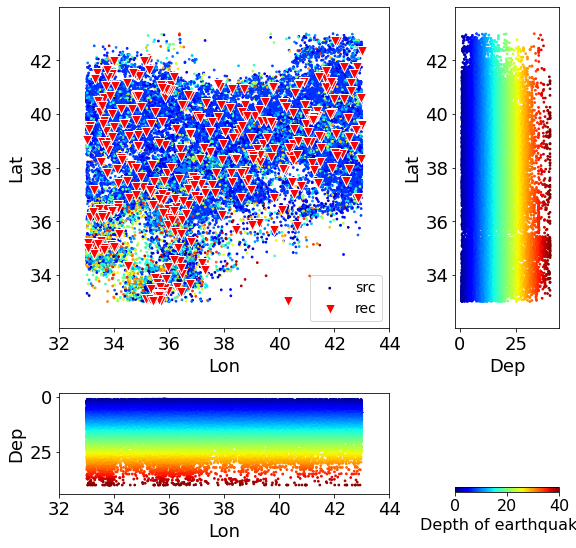

In [3]:
# 读取数据
fname = "traveltime_data/src_rec_Turkey.dat"
[ev_info_obs, st_info_obs] = ffd.read_src_rec_file(fname)

# 数据画图（可选） fname = None 可以不保存图片
ffd.fig_ev_st_distribution_dep(ev_info_obs, st_info_obs, fname = "figs/step1_original_data.png")


# 2. 选定研究区域
### 1. 研究区域是 一个以 (central_lon, central_lat) 为中心的矩形，
### 2. y方向范围为 [central_lat+lat1, central_lat+lat2]， x方向范围为 [central_lon+lon1, central_lon+lon2]
### 3. 然后对研究区域进行顺时针旋转 rotation_angle 度

In [4]:
central_lat = 37.0      # 旋转中心纬度
central_lon = 37.0      # 旋转中心经度
rotation_angle = 45.0   # 顺时针旋转角度

lat1 = -2.0;    lat2 = 3.0;     # 研究区域 y 方向范围
lon1 = -1.3;    lon2 = 1.3;     # 研究区域 x 方向范围
dep1 =  0.5;    dep2 = 40.0;    # 研究区域深度方向范围

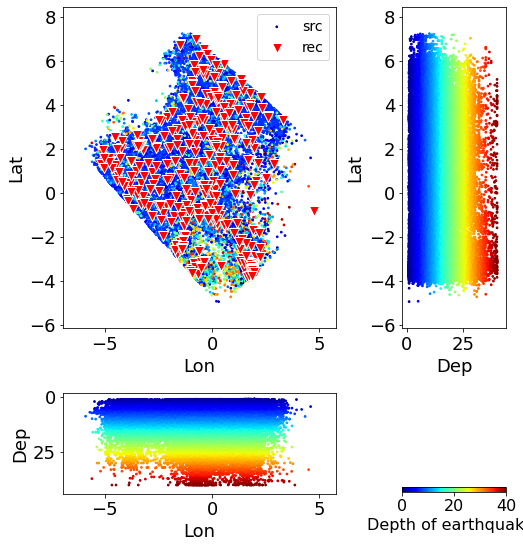

In [5]:
# 如果研究区域是规则经纬度范围，无需旋转的话，可省略该步骤。

# 首先对所有地震与台站坐标进行旋转。满足：
# 1. 坐标原始地理位置 (central_lon,central_lat) 将变为经纬度 (0,0)。
# 2. 逆时针旋转 rotation_angle 角度。（PS：对数据逆时针旋转等价于研究区域顺时针选择）
[ev_rot, st_rot] = ffd.rotate_src_rec(ev_info_obs,st_info_obs,central_lat,central_lon,rotation_angle)

# 数据画图（可选）
ffd.fig_ev_st_distribution_dep(ev_rot, st_rot, fname = "figs/step1_rotated_data.png")


delete 77899 events out of the region, now 66672 earthquakes are retained within the study region


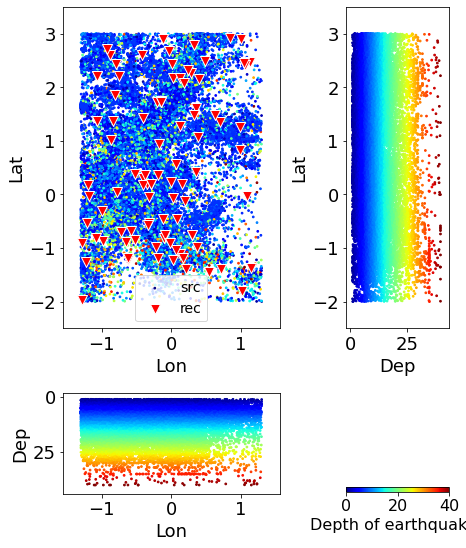

In [6]:
# 删除研究区域外的地震
ev_rot_indom = ffd.limit_ev_region(ev_rot,lat1,lat2,lon1,lon2,dep1,dep2)

# 删除研究区域外的到时数据
ev_rot_indom = ffd.limit_st_region(ev_rot_indom,st_rot,lat1,lat2,lon1,lon2)

# 数据画图（可选）
ffd.fig_ev_st_distribution_dep(ev_rot_indom, st_rot, fname = "figs/step1_rotated_indom_data.png")

# 3. 数据输出

In [7]:
# 将数据输出到指定目录
import os

# 指定数据目录
out_path = "output_data"
os.makedirs(out_path,exist_ok=True)

# 储存为TomoATT格式数据文件
out_fname = "%s/step1_src_rec_indom.dat"%(out_path)
ffd.write_src_rec_file(out_fname,ev_rot_indom,st_rot)

src_rec.dat has been outputed: 66337 events, 95 stations, 489988 abs traveltime, 0 cs_dif traveltime, 0 cr_dif traveltime. 
earthquake and station region, lat:   -2.0 -    3.0, lon:   -1.3 -    1.3, dep:   -1.9 -   40.0


# 4. （可选）还原到现实坐标，观察数据分布

src_rec.dat has been outputed: 66337 events, 95 stations, 489988 abs traveltime, 0 cs_dif traveltime, 0 cr_dif traveltime. 
earthquake and station region, lat:   34.8 -   40.0, lon:   34.1 -   40.8, dep:   -1.9 -   40.0


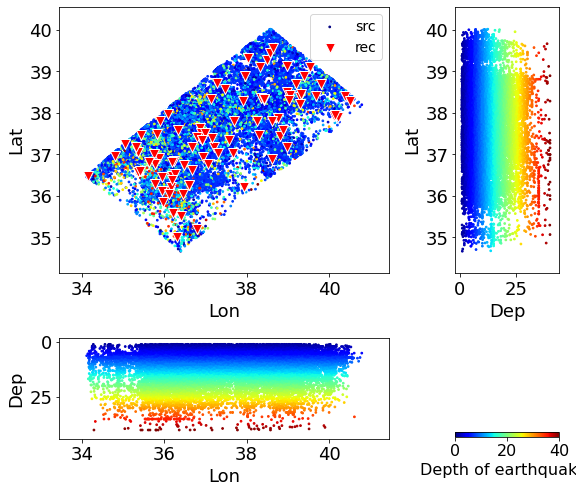

In [8]:
# 将数据旋转回原始地理位置
[ev_indom, st_indom] = ffd.rotate_src_rec_reverse(ev_rot_indom, st_rot,central_lat,central_lon,rotation_angle)

# 数据画图 （可选）
ffd.fig_ev_st_distribution_dep(ev_indom, st_indom, fname = "figs/step1_indom_data.png")

# 真实地震列表
out_fname_ev = "%s/step1_ev_list.dat"%(out_path)
ffd.write_src_list_file(out_fname_ev,ev_indom)

# 真实台站列表
out_fname_st = "%s/step1_st_list.dat"%(out_path)
ffd.write_rec_list_file(out_fname_st,ev_indom,st_indom)

# 真实到时数据
out_fname_tt = "%s/step1_src_rec_data_norot.dat"%(out_path)
ffd.write_src_rec_file(out_fname_tt,ev_indom,st_indom)